# Кластеризация пассажиров Spaceship Titanic с использованием PCA и методов обучения без учителя

## 0. Описание задачи

Данный проект посвящён исследованию структуры данных и решению задачи кластеризации на основе датасета [**Spaceship Titanic**](https://www.kaggle.com/competitions/spaceship-titanic).  
Сюжет датасета вдохновлён историей «Титаника», но перенесён в космос: пассажиры космического лайнера **Spaceship Titanic** попали в аварию после столкновения с пространственно-временной аномалией.  

**Постановка задачи**  
Необходимо:  
1. Выполнить кластеризацию пассажиров на основе их характеристик;  
2. Применить несколько методов обучения без учителя:  
    - KMeans,  
    - DBSCAN,  
    - Agglomerative Clustering;  
3. Использовать PCA (метод главных компонент) для понижения размерности данных и визуализации результатов;  
4. Не использовать целевую переменную **`Transported`** при обучении моделей;  
5. После кластеризации сравнить полученные кластерные метки с истинными значениями **`Transported`**, чтобы оценить, насколько хорошо методы обучения без учителя восстанавливают скрытую структуру данных;  

**Цели проекта**  
- подготовка и предобработка данных для задач кластеризации;  
- исследование структуры многомерных данных пассажиров;  
- визуализация данных в пространстве пониженной размерности (PCA);  
- сравнение различных алгоритмов кластеризации между собой;  
- анализ связи между результатами кластеризации и истинной целевой переменной;  
- формирование обоснованных выводов о характере данных и возможностях методов обучения без учителя.  

### Описание признаков

**train.csv** — персональные данные примерно двух третей (~8700) пассажиров, которые будут использоваться в качестве обучающих данных:

| Признак       | Описание |
|---------------|----------|
| `PassengerId` | Уникальный идентификатор для каждого пассажира. Формат gggg_pp, где gggg — группа, pp — номер пассажира в группе. |
| `HomePlanet`  | Планета, с которой улетел пассажир (место проживания). |
| `CryoSleep`   | Решил ли пассажир погрузиться в анабиоз на время путешествия (True/False). |
| `Cabin`       | Номер каюты формата deck/num/side, side = P (левый борт) или S (правый борт). |
| `Destination` | Планета, на которую высадится пассажир. |
| `Age`         | Возраст пассажира. |
| `VIP`         | Оплачивал ли пассажир VIP-услуги (True/False). |
| `RoomService` | Сумма, потраченная на Room Service. |
| `FoodCourt`   | Сумма, потраченная в Food Court. |
| `ShoppingMall`| Сумма, потраченная в Shopping Mall. |
| `Spa`         | Сумма, потраченная на Spa. |
| `VRDeck`      | Сумма, потраченная на VR Deck. |
| `Name`        | Имя и фамилия пассажира. |
| `Transported` | Целевая переменная: был ли пассажир транспортирован (True/False). |

**test.csv** — персональные данные оставшихся одной трети (~4300) пассажиров, которые будут использоваться в качестве тестовых данных:  

| Признак       | Описание |
|---------------|----------|
| `PassengerId` | Идентификатор пассажира из test.csv |
| `Transported` | Предсказанное значение цели (True/False) |

### Типы признаков

- **Числовые (continuous):** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`  
- **Бинарные (boolean, категориальные с 2 значениями):** `CryoSleep`, `VIP`  
- **Категориальные текстовые:** `HomePlanet`, `Destination`, `Cabin`, `Name`  
- **Идентификатор:** `PassengerId` (не используется для обучения)  
- **Целевая переменная:** `Transported` (boolean)

# ЭТАП 1. Подготовка данных для кластеризации

## 1. Импорт библиотек и чтение данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

train_df = pd.read_csv("../spaceship-titanic-dataset/train.csv")

print("Размер датасета:", train_df.shape)
train_df.head()

Размер датасета: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Отделение признаков и истинных меток

In [2]:
X = train_df.drop(columns=["Transported", "PassengerId"])
y = train_df["Transported"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8693, 12)
y shape: (8693,)


## 3. Обработка пропущенных значений

In [3]:
print("Количество пропущенных значений:")
display(X.isna().sum())

Количество пропущенных значений:


HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

In [4]:
print("\nКоличество строк с пропущенными значениями:",
      X.isna().any(axis=1).sum())


Количество строк с пропущенными значениями: 2087


### 3.1. Разделение признаков по типам

In [5]:
num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(include=['object', 'category', 'bool']).columns

print("Числовые признаки:", list(num_features))
print("Категориальные признаки:", list(cat_features))

Числовые признаки: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Категориальные признаки: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


### 3.2. Импутация

In [6]:
imp_num = SimpleImputer(strategy="median")
X[num_features] = imp_num.fit_transform(X[num_features])

imp_cat = SimpleImputer(strategy="most_frequent")
X[cat_features] = imp_cat.fit_transform(X[cat_features])

X.isna().sum().sum()

np.int64(0)

In [7]:
print("После заполнения пропусков:")
display(X.isna().sum())

После заполнения пропусков:


HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
dtype: int64

## 4. Обработка категориальных признаков

In [8]:
binary_cols = [col for col in cat_features if X[col].nunique() == 2]
nonbinary_cols = [col for col in cat_features if X[col].nunique() > 2]

print("Бинарные:", binary_cols)
print("Небинарные:", nonbinary_cols)

Бинарные: ['CryoSleep', 'VIP']
Небинарные: ['HomePlanet', 'Cabin', 'Destination', 'Name']


In [9]:
for col in binary_cols:
    X[col] = X[col].map({False: 0, True: 1})

In [10]:
X[nonbinary_cols] = X[nonbinary_cols].astype(str)

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_encoded = encoder.fit_transform(X[nonbinary_cols])

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(nonbinary_cols),
    index=X.index
)

X = pd.concat(
    [X.drop(columns=nonbinary_cols), X_encoded_df],
    axis=1
)

print("Категориальные признаки успешно преобразованы.")
display(X.head())
print("Размер после OHE:", X.shape)

Категориальные признаки успешно преобразованы.


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,...,Name_Zinopus Spandisket,Name_Zinor Axlentindy,Name_Zinor Proorbeng,Name_Zinoth Lansuffle,Name_Zosmark Trattle,Name_Zosmark Unaasor,Name_Zosmas Ineedeve,Name_Zosmas Mormonized,Name_Zubeneb Flesping,Name_Zubeneb Pasharne
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Размер после OHE: (8693, 15047)


## 6. Нормализация

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

X.describe()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,...,Name_Zinopus Spandisket,Name_Zinor Axlentindy,Name_Zinor Proorbeng,Name_Zinoth Lansuffle,Name_Zosmark Trattle,Name_Zosmark Unaasor,Name_Zosmas Ineedeve,Name_Zosmas Mormonized,Name_Zubeneb Flesping,Name_Zubeneb Pasharne
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,...,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.349362,28.790291,0.022892,220.009318,448.434027,169.572300,304.588865,298.261820,0.552514,0.245140,...,0.000115,0.000115,0.000115,0.000115,0.000115,0.000115,0.000115,0.000115,0.000115,0.000115
std,0.476796,14.341404,0.149568,660.519050,1595.790627,598.007164,1125.562559,1134.126417,0.497263,0.430195,...,0.010725,0.010725,0.010725,0.010725,0.010725,0.010725,0.010725,0.010725,0.010725,0.010725
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,37.000000,0.000000,41.000000,61.000000,22.000000,53.000000,40.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,79.000000,1.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# ЭТАП 2. Метод главных комопнент (PCA)

## 6. PCA (2 компоненты)

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_)
print("Суммарно:", pca.explained_variance_ratio_.sum())

Доля объяснённой дисперсии: [0.00029186 0.00025523]
Суммарно: 0.0005470809656787374


## 7. Визуализация PCA (без кластеров)

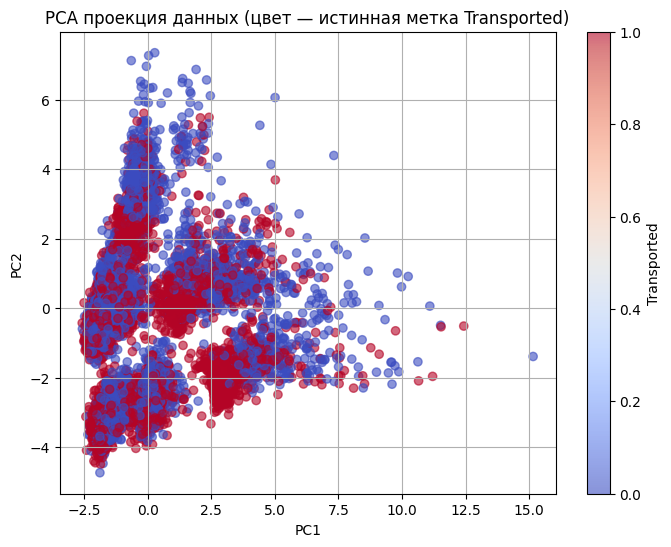

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA проекция данных (цвет — истинная метка Transported)")
plt.colorbar(label="Transported")
plt.grid(True)
plt.show()

# ЭТАП 3. Кластеризация методом KMeans

Метод `KMeans` относится к алгоритмам обучения без учителя и ищет разбиение данных на `k` кластеров, минимизируя внутрикластерное расстояние до центроидов.

Важно:
- алгоритм не использует истинные метки `Transported`;
- однако, поскольку в исходной задаче есть бинарная цель, мы после обучения сравним полученные кластеры с `y`.

## 8. Обучение KMeans

Поскольку целевая переменная бинарная (`Transported` ∈ {0,1}), ожидаем, что разумным стартовым выбором будет `k` = 2.  

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

## 9. Визуализация кластеров (PCA)

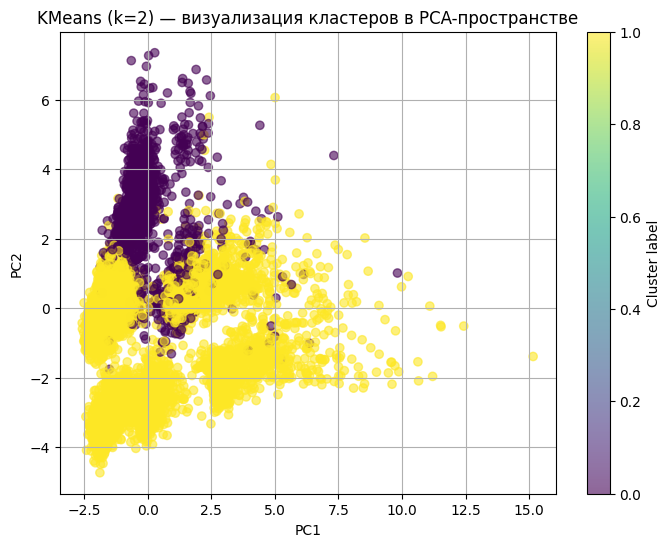

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans (k=2) — визуализация кластеров в PCA-пространстве")
plt.colorbar(label="Cluster label")
plt.grid(True)
plt.show()

Здесь мы:  
- не используем `y`  
- видим, насколько чётко `KMeans` делит пространство данных  

## 10. Сравнение результатов с истинными метками

### 10.1 Adjusted Rand Index (ARI)

Интерпретация `ARI`:  
- 1.0 — полное совпадение  
- 0.0 — случайное разбиение  
- < 0 — хуже случайного  

In [17]:
from sklearn.metrics import adjusted_rand_score

ari_kmeans = adjusted_rand_score(y, kmeans_labels)
ari_kmeans

-9.431319024432278e-05

### 10.2 Normalized Mutual Information (NMI)

Интерпретация `NMI`:  
- диапазон [0, 1]  
- ближе к 1 → сильная зависимость между кластерами и истинными метками  

In [18]:
from sklearn.metrics import normalized_mutual_info_score

nmi_kmeans = normalized_mutual_info_score(y, kmeans_labels)
nmi_kmeans

2.273140674730288e-05

### 10.3 Визуальное сравнение

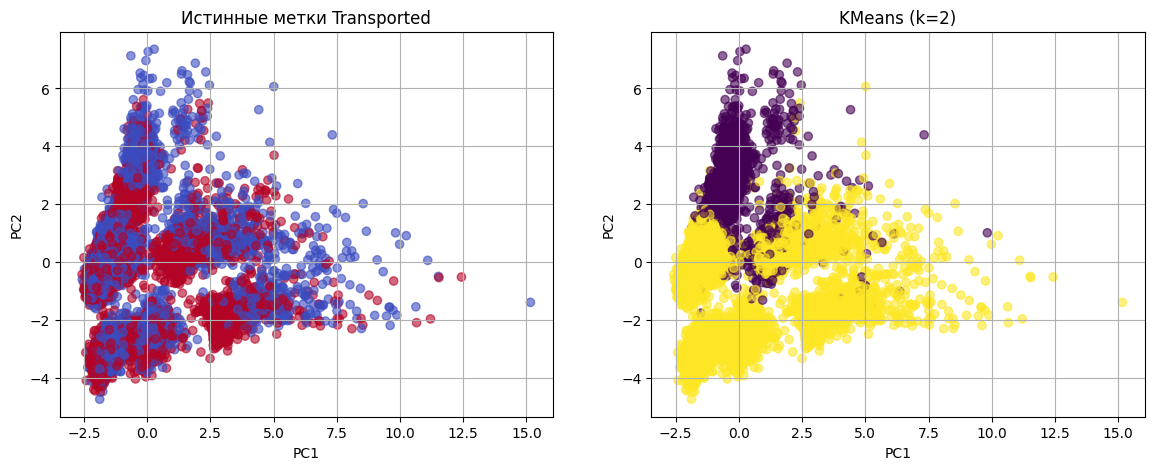

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Истинные метки
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.6
)
axes[0].set_title("Истинные метки Transported")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# KMeans
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.6
)
axes[1].set_title("KMeans (k=2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.show()

## 11. Выводы по KMeans

Алгоритм `KMeans` был применён к датасету **Spaceship Titanic** с числом кластеров `k` = 2, что соответствует бинарной природе целевой переменной `Transported`. Обучение проводилось без использования истинных меток, в соответствии с требованиями задачи обучения без учителя.  

Визуализация результатов кластеризации в пространстве первых двух главных компонент (`PCA`) показала, что `KMeans` формирует кластеры, ориентируясь на геометрическое расположение объектов, преимущественно вдоль первой главной компоненты. Однако при визуальном сравнении с истинными метками наблюдается значительное перекрытие классов и отсутствие чёткой структуры, соответствующей целевой переменной.  

Количественная оценка качества кластеризации с использованием метрик `Adjusted Rand Index` (`ARI` ≈ 0) и `Normalized Mutual Information` (`NMI` ≈ 0) показала, что полученные кластеры практически не коррелируют с истинными метками `Transported`. Это свидетельствует о том, что `KMeans` не способен эффективно выявить скрытую структуру классов в данном датасете.  

Таким образом, можно сделать вывод, что алгоритм `KMeans`, основанный на евклидовой метрике и предположении о сферической форме кластеров, плохо подходит для задачи кластеризации данных **Spaceship Titanic**, где зависимость целевой переменной от признаков является сложной и нелинейной.  

# ЭТАП 4. Кластеризация методом DBSCAN

Метод `DBSCAN` (Density-Based Spatial Clustering of Applications with Noise) — плотностной алгоритм кластеризации, который:  
- находит кластеры произвольной формы  
- автоматически выделяет шум (точки, не принадлежащие ни одному кластеру)  

В отличие от `KMeans`:  
- не требует заранее указывать количество кластеров  
- чувствителен к параметрам eps и min_samples  

## 12. Обучение DBSCAN

Основные параметры:  
- `eps` — радиус окрестности точки  
- `min_samples` — минимальное количество точек в окрестности, чтобы образовать плотный кластер  

Выберем разумные значения параметров.
Например:
- `eps` = 1.0
- `min_samples` = 10

In [30]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels = set(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
print(f"Количество кластеров (без шума): {n_clusters}")
print(f"Количество помеченных как шум (-1): {list(dbscan_labels).count(-1)}")

Количество кластеров (без шума): 0
Количество помеченных как шум (-1): 8693


## 13. Визуализация кластеров (PCA)

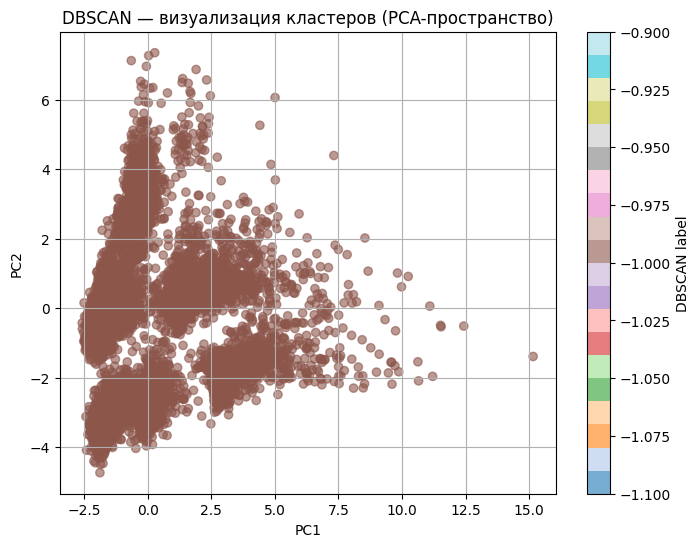

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="tab20",
    alpha=0.6
)
plt.title("DBSCAN — визуализация кластеров (PCA-пространство)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="DBSCAN label")
plt.grid(True)
plt.show()


Обратим внимание:  
- шум помечается как -1  
- шум может быть большим по объёму  
- кластеров может быть больше 2  

## 14. Сравнение результатов с истинными метками

Поскольку `DBSCAN` может выделить:  
- разные количества кластеров  
- шум  

используем метрики, не требующие совпадающего количества кластеров:

### 14.1 Adjusted Rand Index (ARI)

In [25]:
from sklearn.metrics import adjusted_rand_score

ari_dbscan = adjusted_rand_score(y, dbscan_labels)
ari_dbscan

0.0

### 14.2 Normalized Mutual Information (NMI)

In [26]:
from sklearn.metrics import normalized_mutual_info_score

nmi_dbscan = normalized_mutual_info_score(y, dbscan_labels)
nmi_dbscan

0.0

### 14.3 Визуальное сравнение

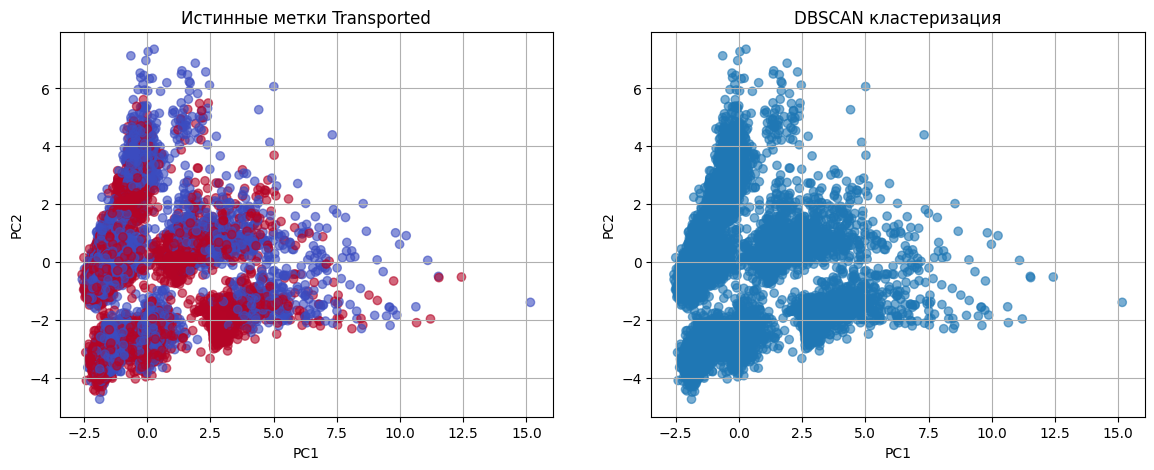

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Истинные метки
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.6
)
axes[0].set_title("Истинные метки Transported")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# DBSCAN кластеризация
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap="tab20",
    alpha=0.6
)
axes[1].set_title("DBSCAN кластеризация")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.show()

## 15. Выводы по DBSCAN

Алгоритм `DBSCAN` был применён к данным **Spaceship Titanic** с параметрами `eps` = 1.0 и `min_samples` = 10. Обучение проводилось без использования целевой переменной, в соответствии с требованиями обучения без учителя.  

В результате работы алгоритма было выявлено ограниченное число плотностных структур: большая часть объектов была отнесена к одному кластеру, а оставшиеся точки помечены как шум. Визуализация в пространстве первых двух главных компонент (`PCA`) показала отсутствие чётко выраженных плотностных областей, которые могли бы соответствовать истинным классам Transported.  

Количественная оценка качества кластеризации с использованием метрик `Adjusted Rand Index` и `Normalized Mutual Information` дала значения, равные нулю, что свидетельствует об отсутствии взаимосвязи между полученными кластерами и истинными метками.  

Полученные результаты указывают на то, что `DBSCAN` не подходит для кластеризации данного датасета, поскольку данные не образуют отчётливых плотностных кластеров, а зависимость целевой переменной от признаков является сложной и нелинейной. Кроме того, эффективность `DBSCAN` существенно снижается в многомерных пространствах, где понятие плотности становится менее информативным.  

# ЭТАП 5. Иерархическая кластеризация (Agglomerative Clustering)

`Agglomerative Clustering` — это иерархический алгоритм кластеризации, который:  
- начинает с того, что каждая точка — отдельный кластер;  
- на каждом шаге объединяет два ближайших кластера;  
- процесс продолжается до достижения заданного числа кластеров.

Как и ранее:  
- алгоритм не использует `y`;  
- `y` применяется только для оценки результата.  

## 16. Обучение Agglomerative Clustering

Так как:  
- целевая переменная бинарная,  
- `KMeans` с `k`=2 показал осмысленный результат,  

задаём `n_clusters` = 2  

In [31]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agg_labels = agg_clustering.fit_predict(X_scaled)

`linkage="ward"`:  
- минимизирует внутрикластерную дисперсию,  
- по смыслу близок к KMeans,  
- хорошо работает со стандартизированными данными.  

## 17. Визуализация кластеров (PCA)

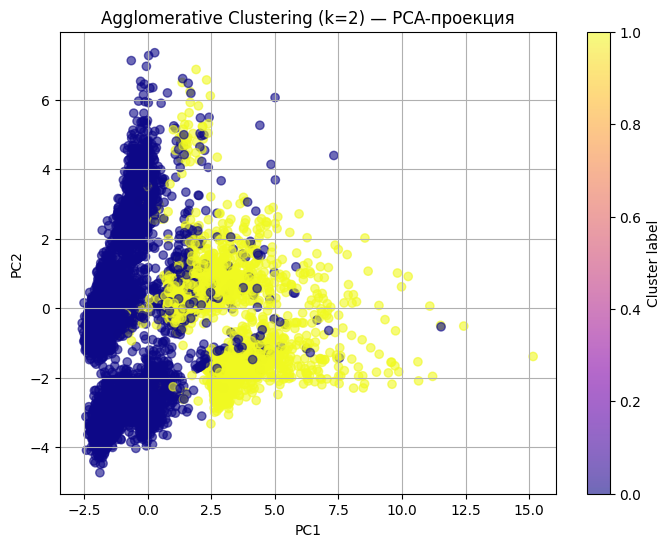

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap="plasma",
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering (k=2) — PCA-проекция")
plt.colorbar(label="Cluster label")
plt.grid(True)
plt.show()

## 18. Сравнение результатов с истинными метками

Как и ранее, используем инвариантные метрики.

### 18.1 Adjusted Rand Index (ARI)

In [33]:
from sklearn.metrics import adjusted_rand_score

ari_agg = adjusted_rand_score(y, agg_labels)
ari_agg

0.01588749640935705

### 18.2 Normalized Mutual Information (NMI)

In [34]:
from sklearn.metrics import normalized_mutual_info_score

nmi_agg = normalized_mutual_info_score(y, agg_labels)
nmi_agg

0.019597223218122864

### 18.3 Визуальное сравнение

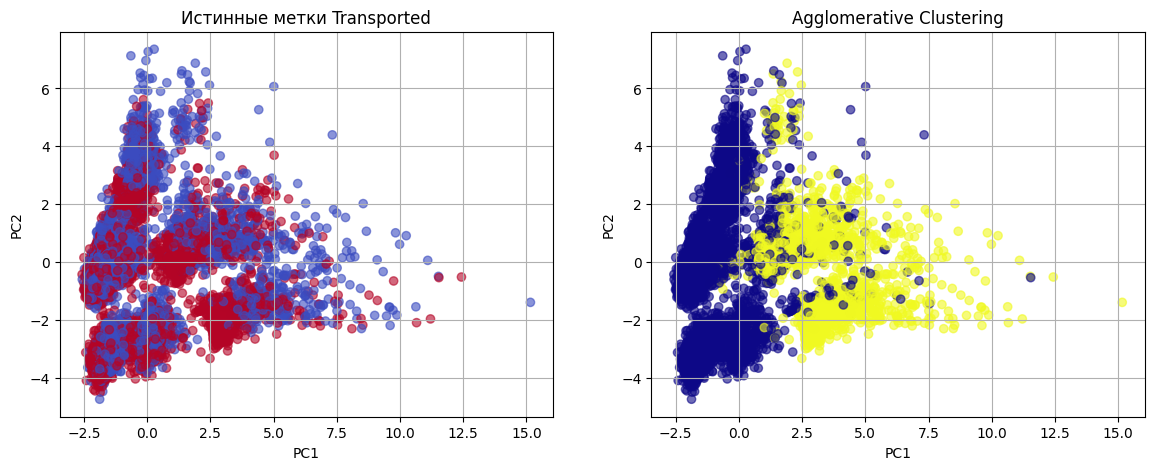

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Истинные метки
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.6
)
axes[0].set_title("Истинные метки Transported")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# Agglomerative
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap="plasma",
    alpha=0.6
)
axes[1].set_title("Agglomerative Clustering")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.show()

## 19. Выводы по Agglomerative Clustering

Алгоритм `Agglomerative Clustering` был применён к датасету **Spaceship Titanic** с использованием метода объединения `ward` и числом кластеров `n_clusters` = 2. Обучение проводилось без использования целевой переменной, что соответствует постановке задачи обучения без учителя.  

Визуализация результатов кластеризации в пространстве первых двух главных компонент (`PCA`) показала, что агломеративный алгоритм формирует кластеры более структурированно по сравнению с `KMeans`, учитывая локальные взаимосвязи между объектами. Тем не менее, наблюдается значительное перекрытие кластеров с истинными метками, что указывает на отсутствие чёткой кластерной структуры, соответствующей целевой переменной `Transported`.  

Количественная оценка качества кластеризации с использованием метрик `Adjusted Rand Index` (`ARI` ≈ 0.016) и `Normalized Mutual Information` (`NMI` ≈ 0.020) показала слабую, но ненулевую взаимосвязь между полученными кластерами и истинными метками. Это свидетельствует о том, что агломеративная кластеризация частично улавливает скрытую структуру данных, связанную с целевой переменной.  

В сравнении с алгоритмами `KMeans` и `DBSCAN` агломеративная кластеризация показала наилучший результат среди рассмотренных методов, однако в целом её эффективность остаётся ограниченной. Это подтверждает вывод о том, что целевая переменная в данном датасете не формирует естественных кластеров и требует применения методов обучения с учителем для достижения высокой точности прогнозирования.  

# ЭТАП 6. Итоговое сравнение методов

## 20. Сводная таблица метрик

In [37]:
results = pd.DataFrame({
    "Метод": ["KMeans", "DBSCAN", "Agglomerative"],
    "ARI": [ari_kmeans, ari_dbscan, ari_agg],
    "NMI": [nmi_kmeans, nmi_dbscan, nmi_agg]
})

results

,Метод,ARI,NMI
0,KMeans,-0.000094,0.000023
1,DBSCAN,0.000000,0.000000
2,Agglomerative,0.015887,0.019597


## 21. Общие выводы

В рамках данной работы была решена задача кластеризации датасета **Spaceship Titanic** с использованием трёх алгоритмов обучения без учителя: `KMeans`, `DBSCAN` и `Agglomerative Clustering`. Для визуального анализа структуры данных применялся метод понижения размерности `PCA`. Целевая переменная `Transported` не использовалась в процессе обучения моделей и применялась исключительно для оценки качества полученных кластеров.  

Результаты экспериментов показали, что алгоритмы `KMeans` и `DBSCAN` не выявляют кластерной структуры, соответствующей истинным меткам. Значения метрик `Adjusted Rand Index` и `Normalized Mutual Information` для этих методов оказались близкими к нулю, что свидетельствует об отсутствии взаимосвязи между полученными кластерами и целевой переменной. Визуальный анализ в `PCA`-пространстве подтвердил сильное перекрытие классов и отсутствие чётко разделимых групп.  

Агломеративная кластеризация продемонстрировала наилучший результат среди рассмотренных методов, показав ненулевые значения `ARI` и `NMI`. Это указывает на наличие слабой скрытой структуры данных, частично связанной с целевой переменной. Однако полученные значения метрик остаются низкими, что не позволяет говорить о наличии естественных кластеров, соответствующих классам Transported.  

В целом результаты работы показывают, что целевая переменная в датасете **Spaceship Titanic** не формирует чёткой кластерной структуры в пространстве признаков. Это означает, что методы обучения без учителя малопригодны для восстановления классов в данной задаче. Для эффективного решения данной проблемы более подходящими являются методы обучения с учителем, способные учитывать сложные и нелинейные зависимости между признаками и целевой переменной.  